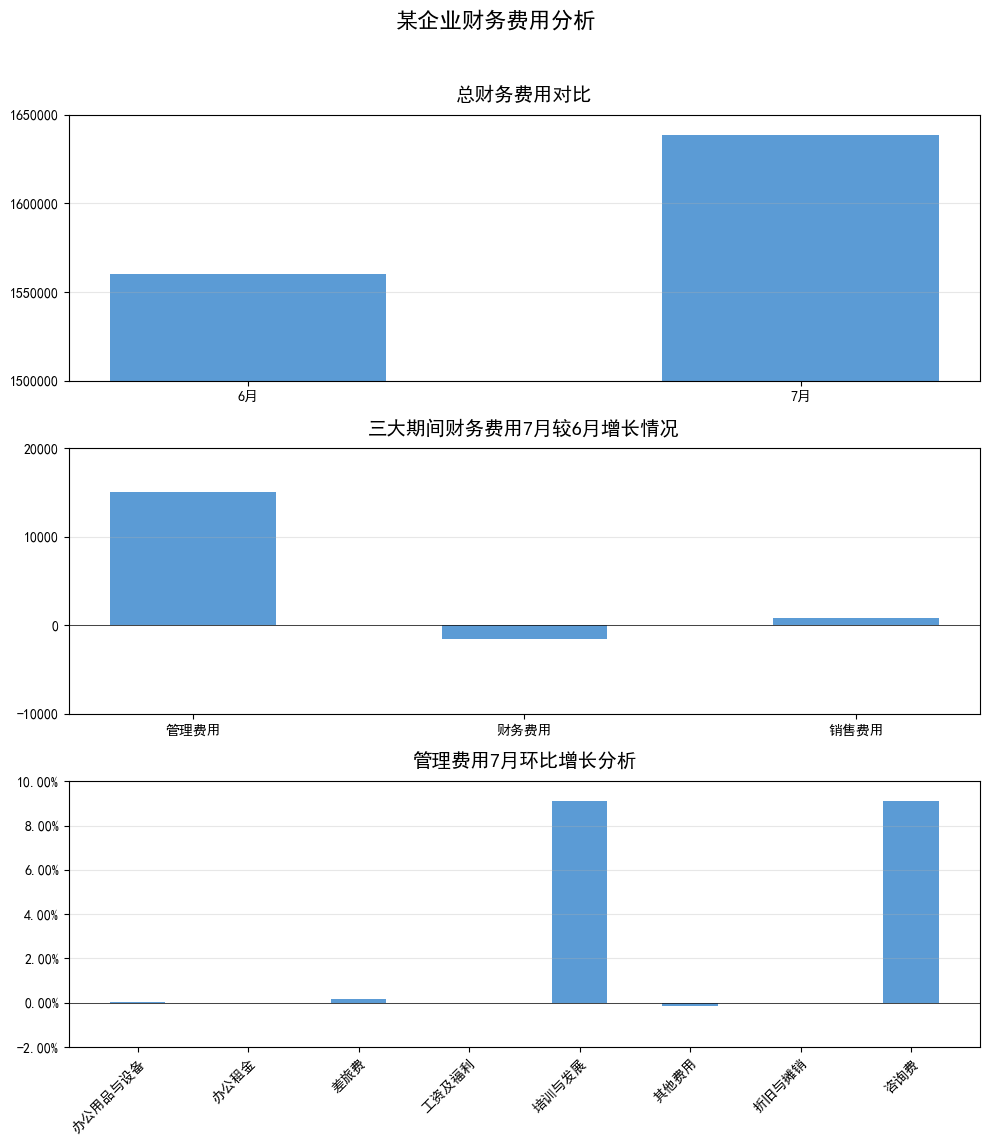

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# ================= 1. 全局设置 =================
# 设置中文字体 (Windows用SimHei，Mac用Arial Unicode MS)
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

# ================= 2. 数据准备 =================
# 图1数据：总财务费用 (取自表1)
months_total = ['6月', '7月']
total_expenses = [1560000, 1638600]

# 图2数据：三大期间费用 (取自表2)
# 注意：图表中的X轴顺序是 管理费用, 财务费用, 销售费用
categories_3 = ['管理费用', '财务费用', '销售费用']
expense_jun_3 = [1064900, 200000, 300000]  # 6月数据
expense_jul_3 = [1079950, 198500, 300800]  # 7月数据
# 计算增长额 (7月 - 6月)
growth_amount_3 = [j - i for i, j in zip(expense_jun_3, expense_jul_3)]

# 图3数据：管理费用明细 (取自表3)
# 注意：为了完全复刻图表，X轴顺序按照截图中的顺序排列
categories_detail = ['办公用品与设备', '办公租金', '差旅费', '工资及福利', '培训与发展', '其他费用', '折旧与摊销', '咨询费']
# 对应6月数据 (需根据类别手动匹配)
detail_jun = [110000, 110000, 59900, 330000, 55000, 70000, 220000, 110000]
# 对应7月数据
detail_jul = [110050, 110000, 60000, 330000, 60000, 69900, 220000, 120000]
# 计算环比增长率 (7月 - 6月) / 6月
growth_rate_detail = [(j - i) / i if i != 0 else 0 for i, j in zip(detail_jun, detail_jul)]


# ================= 3. 绘图 =================
# 创建一个大的画布，包含3行1列的子图
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
fig.suptitle('某企业财务费用分析', fontsize=16, fontweight='bold', y=0.95)

color_bar = '#5B9BD5' # 模仿Excel默认的蓝色

# --- 图1：总财务费用对比 ---
ax1 = axes[0]
ax1.bar(months_total, total_expenses, color=color_bar, width=0.5)
ax1.set_title('总财务费用对比', fontsize=14, pad=10)
ax1.set_ylim(1500000, 1650000) # 强制Y轴范围以匹配截图
ax1.set_yticks([1500000, 1550000, 1600000, 1650000])
# 格式化Y轴标签为整数，不带科学计数法
ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))
ax1.grid(axis='y', linestyle='-', alpha=0.3)
# 添加边框效果
for spine in ax1.spines.values():
    spine.set_edgecolor('black')

# --- 图2：三大期间财务费用7月较6月增长情况 ---
ax2 = axes[1]
ax2.bar(categories_3, growth_amount_3, color=color_bar, width=0.5)
ax2.set_title('三大期间财务费用7月较6月增长情况', fontsize=14, pad=10)
ax2.set_ylim(-10000, 20000)
ax2.set_yticks([-10000, 0, 10000, 20000])
ax2.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))
ax2.axhline(0, color='black', linewidth=0.5) # 0轴线
ax2.grid(axis='y', linestyle='-', alpha=0.3)
for spine in ax2.spines.values():
    spine.set_edgecolor('black')

# --- 图3：管理费用7月环比增长分析 ---
ax3 = axes[2]
ax3.bar(categories_detail, growth_rate_detail, color=color_bar, width=0.5)
ax3.set_title('管理费用7月环比增长分析', fontsize=14, pad=10)
ax3.set_ylim(-0.02, 0.10) # 范围 -2% 到 10%
ax3.set_yticks([-0.02, 0.00, 0.02, 0.04, 0.06, 0.08, 0.10])
# 格式化Y轴为百分比
ax3.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x*100:.2f}%'))
ax3.axhline(0, color='black', linewidth=0.5)
ax3.grid(axis='y', linestyle='-', alpha=0.3)
# 旋转X轴标签
plt.setp(ax3.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
for spine in ax3.spines.values():
    spine.set_edgecolor('black')

plt.tight_layout(rect=[0, 0, 1, 0.93]) # 调整布局给大标题留空间
plt.show()